Dissipation slices of various places

In [16]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import time

import richio
import unyt as u
import dev

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
path = "/data1/projects/pi-rossiem/TDE_data/R0.47M0.5BH10000beta1S60n1.5ComptonHiResNewAMR/snap_76"

In [18]:
snap = richio.load(path)

In [19]:
X = snap.CMx
Y = snap.CMy
Z = snap.CMz
r = np.sqrt(X**2 + Y**2 + Z**2)

In [20]:
B = (
    -u.G * 1e4 * richio.units.mscale / r
    + 0.5 * (snap.vx**2 + snap.vy**2 + snap.vz**2)
    + snap.sie
    + (snap.P / snap.rho + snap.Erad / 3)
)

In [21]:
vr = (snap.vx * X + snap.vy * Y + snap.vz * Z) / r

In [22]:
peri_wind_mask = (B > 0) & (X > 0) & (vr > 0)  # & (Z / r < 0.5)
wind_mask = (B > 0) & (vr > 0)  # & (Z / r < 0.5)

In [23]:
B[peri_wind_mask].max()

unyt_quantity(4.866279e+18, 'm**2/s**2')

In [24]:
most_unbound_peri_wind = np.argmax(B[peri_wind_mask])

In [25]:
(
    X[peri_wind_mask][most_unbound_peri_wind],
    Y[peri_wind_mask][most_unbound_peri_wind],
    Z[peri_wind_mask][most_unbound_peri_wind],
)

(unyt_quantity(1.05308105, 'code_length'),
 unyt_quantity(2.75897649, 'code_length'),
 unyt_quantity(0.88024395, 'code_length'))

In [26]:
masked_density = snap.density
masked_density[~wind_mask] = 0

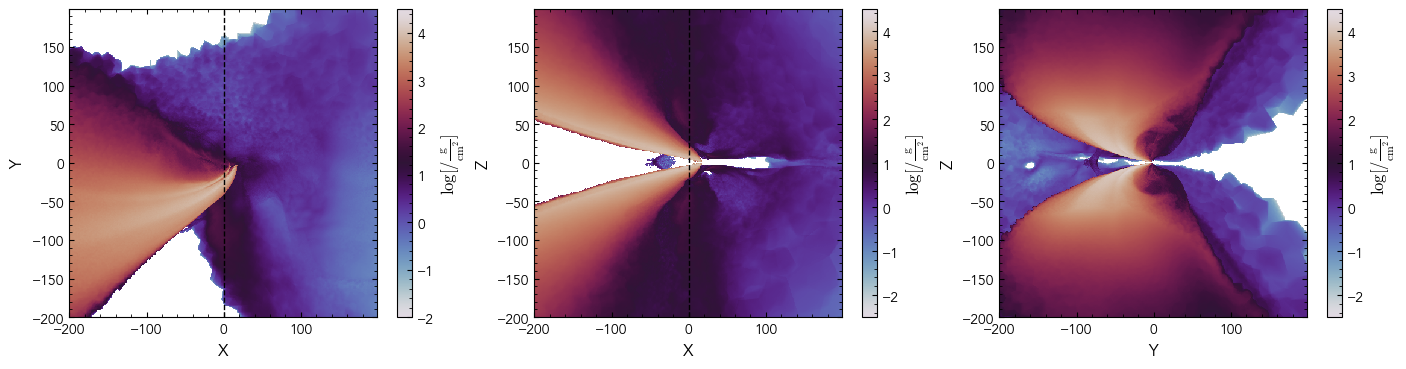

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

ax, im, projected_data = snap.plots.projection(
    data=masked_density,
    res=512,
    X="CMx",
    Y="CMy",
    Z="CMz",
    plane="xy",
    box_size=(-200, -200, -200, 200, 200, 200),
    ax=axes[0],
)
axes[0].axvline(0, color="k", linestyle="--")
axes[0].set_xlabel("X")
axes[0].set_ylabel("Y")

ax, im, projected_data = snap.plots.projection(
    data=masked_density,
    res=512,
    X="CMx",
    Y="CMy",
    Z="CMz",
    plane="xz",
    box_size=(-200, -200, -200, 200, 200, 200),
    ax=axes[1],
)
axes[1].axvline(0, color="k", linestyle="--")
axes[1].set_xlabel("X")
axes[1].set_ylabel("Z")

ax, im, projected_data = snap.plots.projection(
    data=masked_density,
    res=512,
    X="CMx",
    Y="CMy",
    Z="CMz",
    plane="yz",
    box_size=(-200, -200, -200, 200, 200, 200),
    ax=axes[2],
)
axes[2].set_xlabel("Y")
axes[2].set_ylabel("Z")

plt.show()

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

ax, im, projected_data = snap.plots.projection(
    data=masked_density,
    res=512,
    X="CMx",
    Y="CMy",
    Z="CMz",
    plane="xy",
    box_size=(-30, -30, -30, 30, 30, 30),
    ax=axes[0],
)
axes[0].axvline(0, color="k", linestyle="--")
axes[0].set_xlabel("X")
axes[0].set_ylabel("Y")

ax, im, projected_data = snap.plots.projection(
    data=masked_density,
    res=512,
    X="CMx",
    Y="CMy",
    Z="CMz",
    plane="xz",
    box_size=(-30, -30, -30, 30, 30, 30),
    ax=axes[1],
)
axes[1].axvline(0, color="k", linestyle="--")
axes[1].set_xlabel("X")
axes[1].set_ylabel("Z")

ax, im, projected_data = snap.plots.projection(
    data=masked_density,
    res=512,
    X="CMx",
    Y="CMy",
    Z="CMz",
    plane="yz",
    box_size=(-30, -30, -30, 30, 30, 30),
    ax=axes[2],
)
axes[2].set_xlabel("Y")
axes[2].set_ylabel("Z")

plt.show()


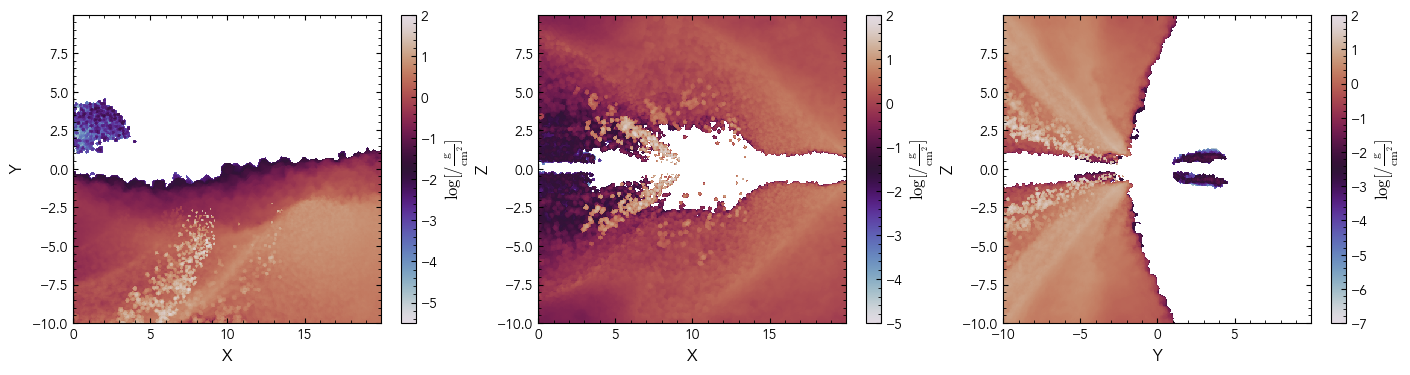

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

ax, im, projected_data = snap.plots.projection(
    data=masked_density,
    res=512,
    X="CMx",
    Y="CMy",
    Z="CMz",
    plane="xy",
    box_size=(0, -10, -10, 20, 10, 10),
    ax=axes[0],
)
axes[0].axvline(0, color="k", linestyle="--")
axes[0].set_xlabel("X")
axes[0].set_ylabel("Y")

ax, im, projected_data = snap.plots.projection(
    data=masked_density,
    res=512,
    X="CMx",
    Y="CMy",
    Z="CMz",
    plane="xz",
    box_size=(0, -10, -10, 20, 10, 10),
    ax=axes[1],
)
axes[1].axvline(0, color="k", linestyle="--")
axes[1].set_xlabel("X")
axes[1].set_ylabel("Z")

ax, im, projected_data = snap.plots.projection(
    data=masked_density,
    res=512,
    X="CMx",
    Y="CMy",
    Z="CMz",
    plane="yz",
    box_size=(0, -10, -10, 20, 10, 10),
    ax=axes[2],
)
axes[2].set_xlabel("Y")
axes[2].set_ylabel("Z")

plt.show()


In [ ]:
masked_dissipation = snap.dissipation
masked_dissipation[~wind_mask] = 0

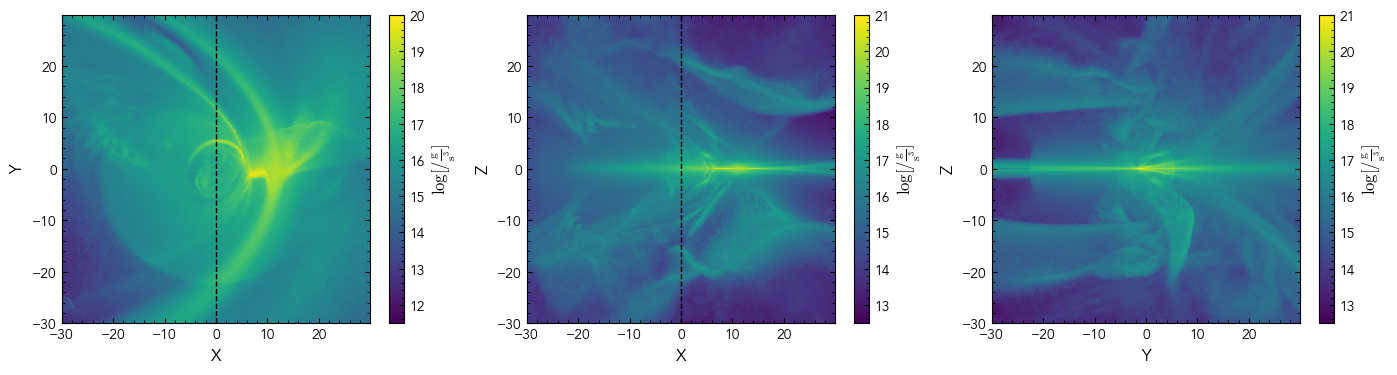

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

ax, im, projected_data = snap.plots.projection(
    data="dissipation",
    res=512,
    X="CMx",
    Y="CMy",
    Z="CMz",
    plane="xy",
    box_size=(-30, -30, -30, 30, 30, 30),
    ax=axes[0],
    cmap="viridis",
)
axes[0].axvline(0, color="k", linestyle="--")
axes[0].set_xlabel("X")
axes[0].set_ylabel("Y")

ax, im, projected_data = snap.plots.projection(
    data="dissipation",
    res=512,
    X="CMx",
    Y="CMy",
    Z="CMz",
    plane="xz",
    box_size=(-30, -30, -30, 30, 30, 30),
    ax=axes[1],
    cmap="viridis",
)
axes[1].axvline(0, color="k", linestyle="--")
axes[1].set_xlabel("X")
axes[1].set_ylabel("Z")

ax, im, projected_data = snap.plots.projection(
    data="dissipation",
    res=512,
    X="CMx",
    Y="CMy",
    Z="CMz",
    plane="yz",
    box_size=(-30, -30, -30, 30, 30, 30),
    ax=axes[2],
    cmap="viridis",
)
axes[2].set_xlabel("Y")
axes[2].set_ylabel("Z")

plt.show()
